# SACD nuclei: segmentation, filtering, and montages

Run this notebook **top to bottom** with the **Cellpose** Python kernel. Edit only the parameter cell for routine runs.

Starting from processed DAPI and SPEN SACD MIPs, this pipeline saves individual nuclei, full-FOV masks, a measurement index, a size histogram, and three ImageJ-compatible montages:

| Output | Nuclei and order |
|---|---|
| `all_nuclei_montage.tif` | Size/boundary-qualified nuclei, grouped by condition and FOV |
| `exp_matched_nuclei_montage.tif` | All eligible nuclei from every condition within the selected reference's masked mean-SPEN range |
| `exp_matched_nuclei_montage-sorted.tif` | Same matched population; **highest to lowest mean SPEN within each condition**, left-to-right then top-to-bottom |

Each TIFF has **DAPI, SPEN, and nucleus-mask channels**. Fluorescence intensities and pixel size are preserved. Text overlays identify nuclei without altering pixels. Inspect the TIFFs in Fiji yourself; this notebook does not launch Fiji.

## 1. Setup

Choose the kernel using `/opt/miniconda3/envs/cellpose/bin/python` (registered as `conda-cellpose`). Open this notebook from the repository or its segmentation folder.

The environment is prepared on this machine. On another machine, install the scientific dependencies plus `rich`, `ipywidgets`, and `ipykernel`. `nbformat` and `nbclient` are needed only for programmatic notebook validation/execution. There are **no automatic package installs** in this notebook. Rich progress falls back to text if Rich is unavailable.

In [1]:
from pathlib import Path
import sys
import importlib.util
from IPython.display import display, Markdown, Image

required = ["numpy", "scipy", "tifffile", "roifile", "matplotlib", "cellpose"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError(f"Missing packages: {', '.join(missing)}. Select the Cellpose kernel or install them first.")

candidates = [candidate for parent in (Path.cwd(), *Path.cwd().parents)
              for candidate in (parent / "cli_sacd_nuclei.py",
                                parent / "image_analysis/segmentation/cli_sacd_nuclei.py")]
script_path = next((path for path in candidates if path.is_file()), None)
if script_path is None:
    raise FileNotFoundError("Open the notebook from within the GG-general-GuttmanLab repository.")
spec = importlib.util.spec_from_file_location("sacd_nuclei", script_path)
pipeline = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pipeline)
print(f"Python: {sys.executable}")
print(f"Pipeline: {script_path}")
print("Rich available:", importlib.util.find_spec("rich") is not None)

Python: /opt/miniconda3/envs/cellpose/bin/python
Pipeline: /Users/gmgao/GGscripts/GG-general-GuttmanLab/image_analysis/segmentation/cli_sacd_nuclei.py
Rich available: True


## 2. Parameters — edit this cell

**Cached masks are reused automatically** when source files and inference settings agree. Changing size/boundary filters, crop padding, or montage columns only rebuilds outputs.

Changing diameter, Cellpose minimum size, flow threshold, or cell-probability threshold requires new segmentation in normal mode. `CACHE_ONLY=True` instead requires existing masks and **deliberately ignores inference-setting changes**; it fails if inputs changed or masks are missing.

- Size uses mask area, not the crop's bounding box. Exactly 10,000 pixels passes.
- Boundary exclusion requires both proximity within 2 pixels and a bounding-box ratio greater than 1.2.
- Mean SPEN is calculated strictly inside each mask without normalization or background subtraction. The selected reference condition's inclusive min/max is calculated after size/boundary filtering.
- Conditions come from the filename prefix before `-DAPI-`; expression matching accepts every discovered condition; choose the reference below.
- For a small trial, set `TRIAL=True` and use a separate `OUTPUT_DIR` so the main results are not replaced. A `FOV_LIMIT` must still include the selected reference condition.
- Rerunning replaces generated crops, indexes, and montages in the selected output folder; source images and cached full-FOV masks are retained.

**Panel order:** Set `CONDITION_ORDER` to a list of exact condition names in the desired order. It applies to all three montages, the histogram, and summary tables. Unlisted conditions follow in natural alphabetical order. Duplicate or unknown names give an error. The sorted montage still sorts intensity high-to-low *within* each condition.

**Rebuild only:** Keep `CACHE_ONLY = True`, then rerun Parameters → Preflight → Run → Review. This never runs segmentation. Set it to `False` for a new dataset without masks. CLI equivalents: `--rebuild --reference-condition SHA --condition-order SHA dRRM dIDR FVP24h FVPrecover3h`.

In [2]:
# Paths
INPUT_DIR = Path("/Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined")
OUTPUT_DIR = None  # None -> INPUT_DIR / "individual nucleus"

# Cellpose inference (only used when a mask must be generated)
DEVICE = "auto"  # auto, mps, cuda, or cpu
DIAMETER = None  # Optional expected diameter in input pixels
CELLPOSE_MIN_SIZE = 15
FLOW_THRESHOLD = 0.4
CELLPROB_THRESHOLD = 0.0

# Export filters and expression measurement (do not change cached masks)
MIN_NUCLEUS_AREA = 10_000  # pixels; approximately 34.2 um² for this dataset
EDGE_ASPECT_RATIO = 1.2
EDGE_MARGIN = 2  # pixels; accounts for slightly inset Cellpose boundaries
SPEN_CHANNEL = "SPEN_JFX650"
REFERENCE_CONDITION = "SHA"  # Exact condition name; all other conditions are gated automatically

# Crop and montage layout
PADDING = 10  # pixels
MONTAGE_COLUMNS = 10
CONDITION_ORDER = None  # Natural order; or e.g. ["SHA", "dRRM", "dIDR", "FVP24h", "FVPrecover3h"]

# Execution and display
CACHE_ONLY = True  # Rebuild from existing masks only; False enables segmentation when needed
TRIAL = False  # One FOV per condition
FOV_LIMIT = None
RICH_PROGRESS = True

## 3. Read-only preflight

Check the FOV counts, channels, calibration, and reuse summary. This cell neither creates outputs nor loads the model. If `Needs segmentation` is zero, this run will not invoke Cellpose.

In [3]:
args = pipeline.parser().parse_args([str(INPUT_DIR)])
vars(args).update(output=OUTPUT_DIR, device=DEVICE, diameter=DIAMETER,
                  min_size=CELLPOSE_MIN_SIZE, flow_threshold=FLOW_THRESHOLD,
                  cellprob_threshold=CELLPROB_THRESHOLD, min_nucleus_area=MIN_NUCLEUS_AREA,
                  edge_aspect_ratio=EDGE_ASPECT_RATIO, edge_margin=EDGE_MARGIN,
                  spen_channel=SPEN_CHANNEL, reference_condition=REFERENCE_CONDITION, padding=PADDING, columns=MONTAGE_COLUMNS, condition_order=CONDITION_ORDER,
                  rebuild=CACHE_ONLY, trial=TRIAL, limit=FOV_LIMIT,
                  no_progress=not RICH_PROGRESS)
plan = pipeline.preflight(args)
lines = ["| Condition | FOVs |", "|---|---:|"]
lines += [f"| {condition} | {count} |" for condition, count in plan["fovs_by_condition"].items()]
display(Markdown("\n".join(lines)))
print("Channels:", ", ".join(plan["channels"]))
print("Mask area cutoff (um²):", MIN_NUCLEUS_AREA * plan["pixel_area_um2"])
print("Expression reference:", REFERENCE_CONDITION)
print("Condition block order:", list(plan["fovs_by_condition"]))
print("Reusable masks:", plan["cached_masks"])
print("Needs segmentation:", plan["requires_segmentation"])
print("Output:", plan["output"])

| Condition | FOVs |
|---|---:|
| dIDR | 17 |
| dRRM | 20 |
| FVP24h | 40 |
| FVPrecover3h | 6 |
| SHA | 20 |

Channels: DAPI, SPEN_JFX650
Mask area cutoff (um²): 34.22249924882432
Expression reference: SHA
Condition block order: ['dIDR', 'dRRM', 'FVP24h', 'FVPrecover3h', 'SHA']
Reusable masks: 103
Needs segmentation: 0
Output: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual nucleus


## 4. Run the complete pipeline

The FOV bar reports completed fields and cache reuse. Each montage has tile-assembly progress, followed by a separate indeterminate TIFF-writing stage. A completed tile bar alone does not mean the TIFF has finished writing. Interrupted or failed runs show an error and can be rerun using their saved masks.

In [4]:
with pipeline.PipelineProgress(enabled=RICH_PROGRESS) as progress:
    result = pipeline.run(args, progress_callback=progress)

## 5. Review and open the results

The histogram shows the population after boundary filtering but **before size filtering**, with the selected cutoff marked. Rank 1 in the CSV is the highest mean SPEN within its condition among expression-matched nuclei. Separate coordinate columns describe each montage; CSV coordinates are zero-based and ranks are one-based.

The local links below work in viewers that allow local-file access. If your Jupyter frontend blocks them, use the printed absolute output folder to open the files in Finder/Fiji. Hide or show ImageJ text labels with **Image → Overlay**.

| Condition | Size/boundary qualified | Expression matched |
|---|---:|---:|
| dIDR | 49 | 35 |
| dRRM | 64 | 40 |
| FVP24h | 46 | 44 |
| FVPrecover3h | 7 | 7 |
| SHA | 121 | 121 |
| **Total** | **287** | **247** |

Inclusive SHA mean-SPEN range: 47.6664329926 to 383.694891786
Cached FOVs used: 103/103
Output folder: /Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual nucleus


- [all_nuclei_montage.tif](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/all_nuclei_montage.tif)
- [exp_matched_nuclei_montage.tif](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/exp_matched_nuclei_montage.tif)
- [exp_matched_nuclei_montage-sorted.tif](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/exp_matched_nuclei_montage-sorted.tif)
- [nucleus_size_histogram.png](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/nucleus_size_histogram.png)
- [nucleus_index.csv](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/nucleus_index.csv)
- [run_settings.json](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/run_settings.json)
- [nuclei](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/nuclei)
- [masks](file:///Volumes/guttman/users/gmgao/Imaging_ProcessedData/SPEN/SACDfixed/exp_matched_combined/individual%20nucleus/masks)

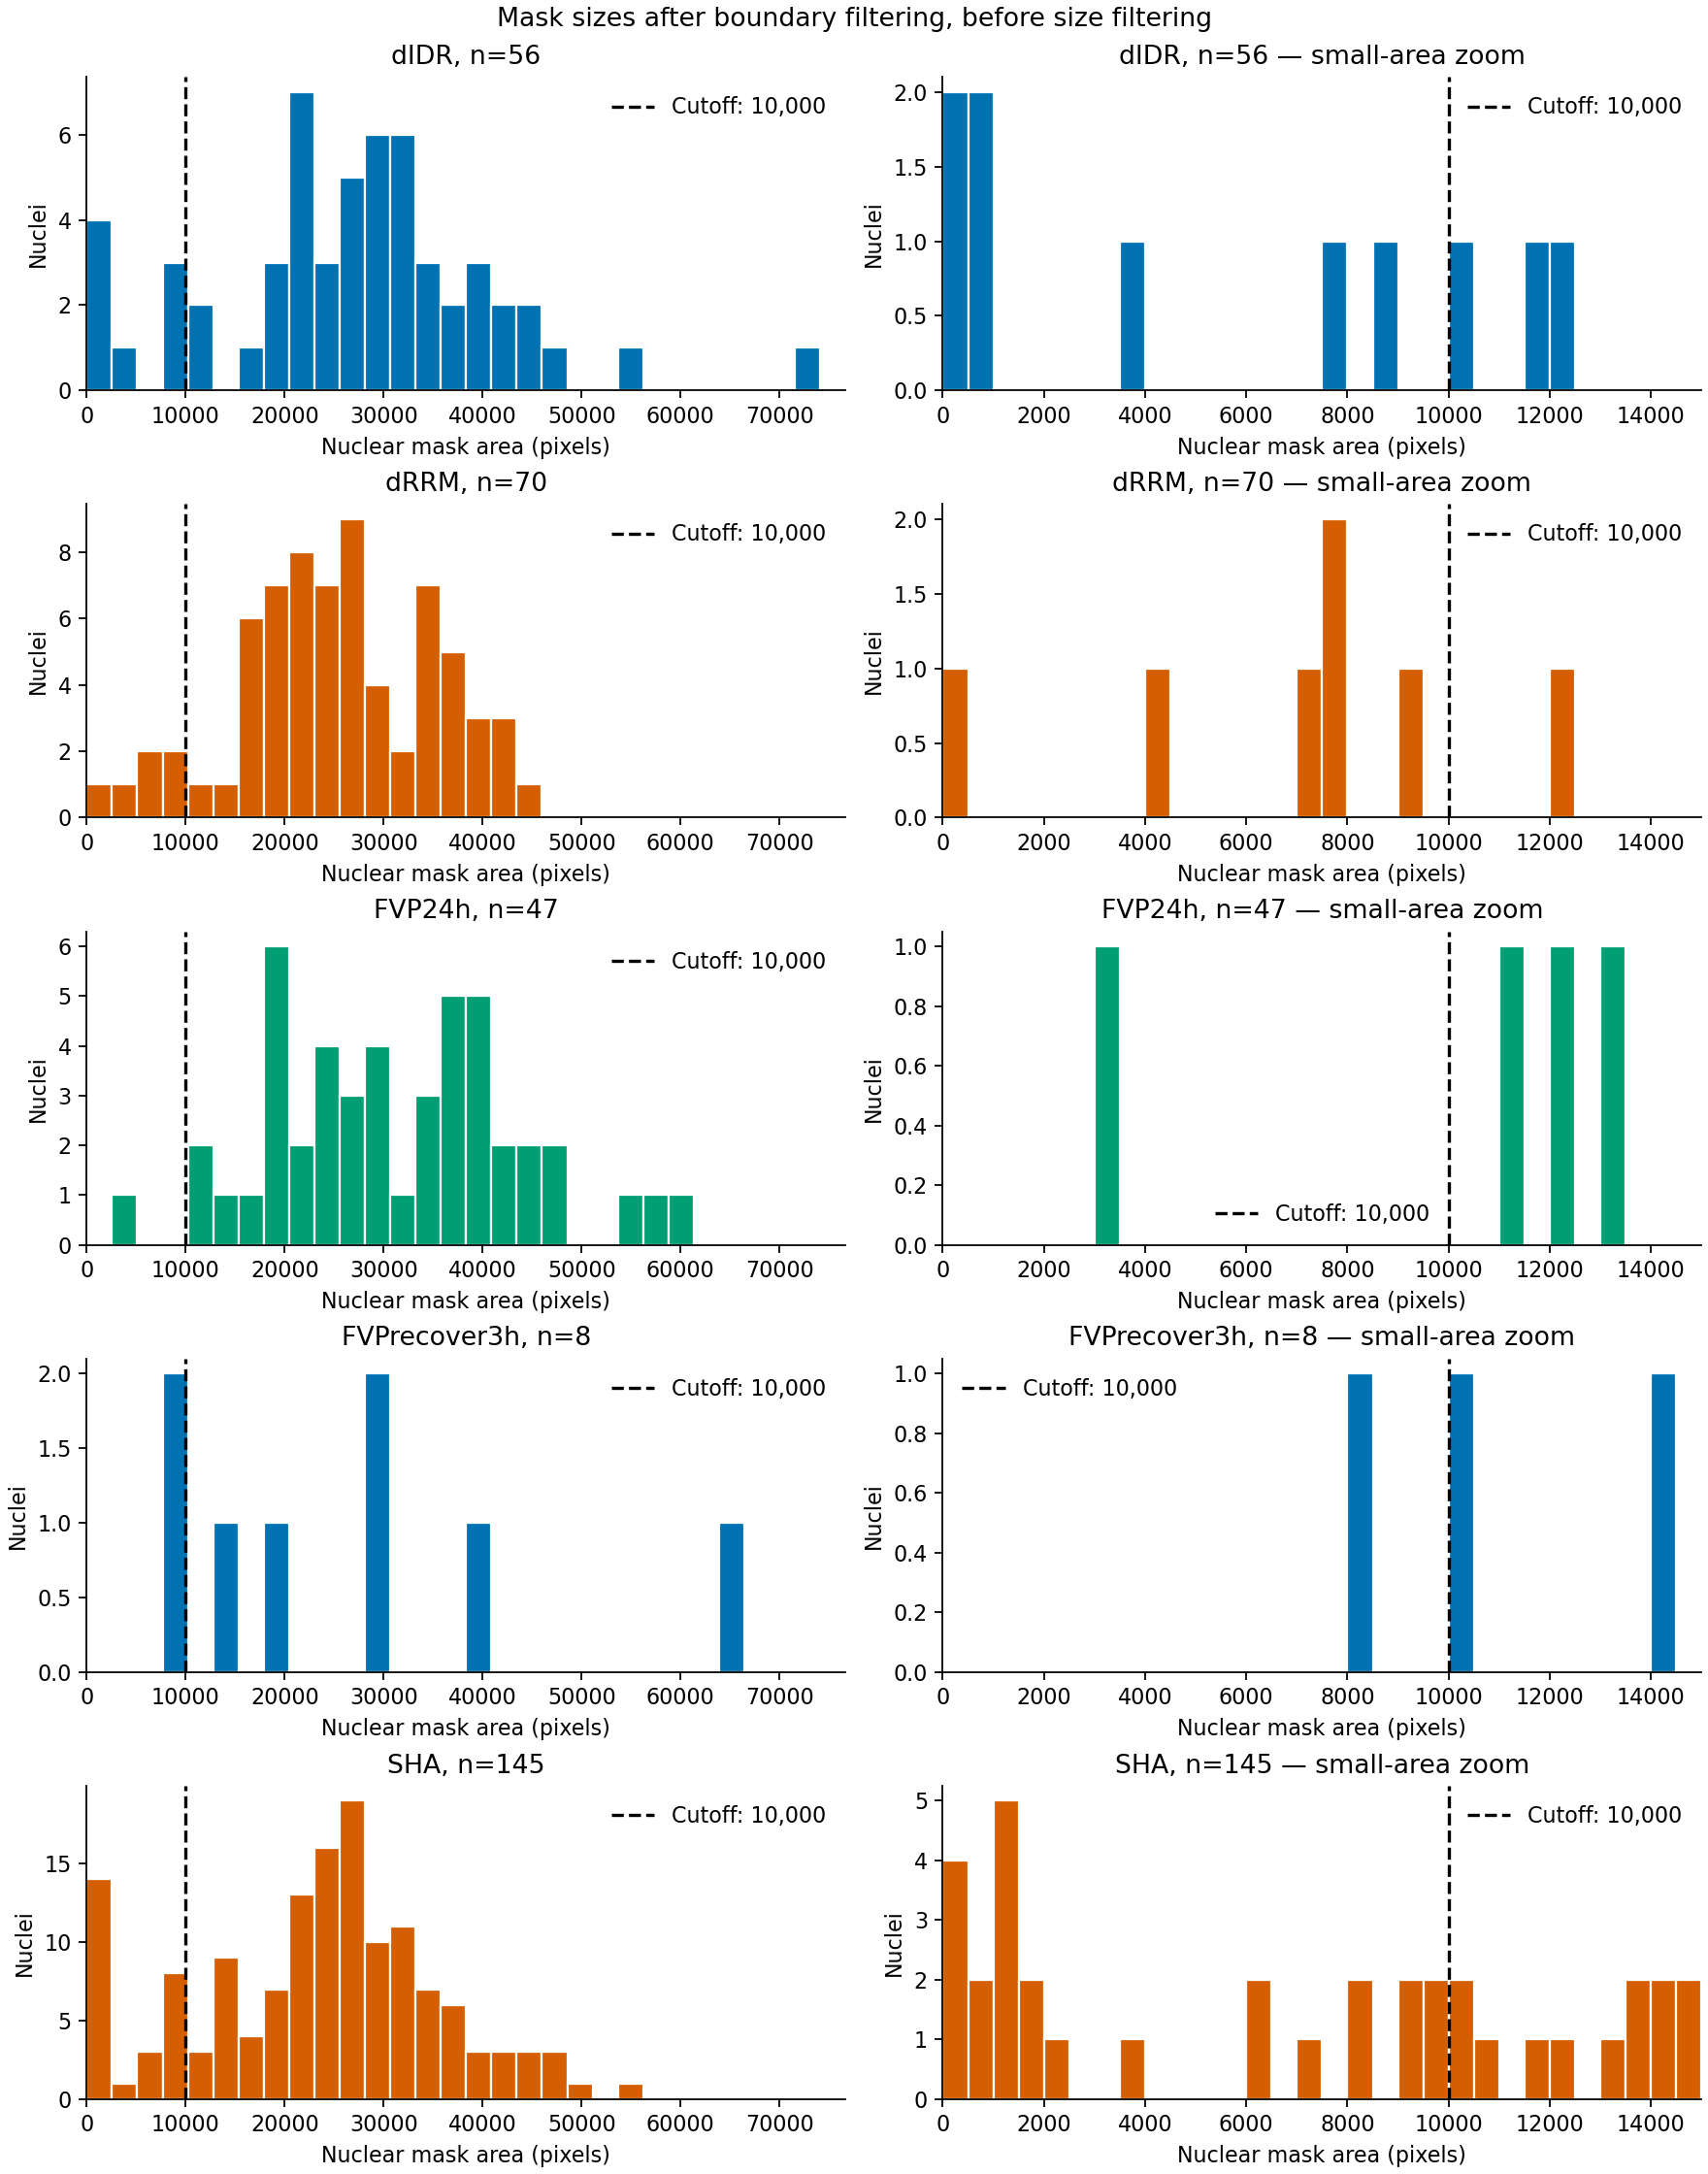

In [5]:
settings = result["settings"]
lines = ["| Condition | Size/boundary qualified | Expression matched |", "|---|---:|---:|"]
for condition, counts in settings["counts_by_condition"].items():
    lines.append(f"| {condition} | {counts['retained']} | {counts['expression_matched']} |")
lines.append(f"| **Total** | **{settings['retained']}** | **{settings['expression_matched']}** |")
display(Markdown("\n".join(lines)))
low, high = settings["reference_mean_spen_range"]
print(f"Inclusive {settings['reference_condition']} mean-SPEN range: {low:.12g} to {high:.12g}")
print(f"Cached FOVs used: {sum(fov['cached'] for fov in settings['fovs'])}/{len(settings['fovs'])}")
print("Output folder:", settings["output"])
display(Markdown("\n".join(f"- [{name}]({path.as_uri()})" for name, path in result["paths"].items())))
display(Image(filename=str(result["paths"]["nucleus_size_histogram.png"]), width=1000))